In [1]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname("__file__"), "..", "scripts"))
sys.path.insert(0, os.path.join(os.path.dirname("__file__"), "..", "style"))

import numpy as np
import matplotlib.pyplot as plt
import math

# Physical constants (CGS)
GMsun = 1.32712440018e26  # G * M_sun in cm^3/s^2
cspeed = 2.99792458e10    # speed of light in cm/s
forbref = 10.0            # reference orbital frequency in Hz


In [2]:
from plot_style import initialize_latex, COLORS
initialize_latex()

In [3]:
# ============================================================
# Function to compute p(e | sigma) for a given velocity dispersion
# ============================================================
# Uses Monte Carlo sampling following Cole & Toonen (2023) prescription

# Eccentricity bounds
log10_e_min, log10_e_max = -11.0, -0.1 
e_min, e_max = 10 ** log10_e_min, 10 ** log10_e_max
ne = 200  # Number of bins (increased for smoother histograms)

# Default sampling parameters
Niter = 40   # Number of velocity draws
Nrp = 200    # Number of pericenter bins per velocity

# Random number generator
rng = np.random.default_rng(42)

def p_e_given_sigma_Mtot_mu(sigma, Mtot, mu, Niter_local=None, Nrp_local=None):
    """
    Vectorized Monte Carlo approximation to p(e | sigma, M, mu).
    
    Parameters
    ----------
    sigma : float
        1D velocity dispersion in cm/s
    Mtot : float
        Total mass in solar masses
    mu : float
        Reduced mass in solar masses
    Niter_local : int, optional
        Number of velocity draws (default: global Niter)
    Nrp_local : int, optional
        Number of pericenter bins per velocity (default: global Nrp)
    
    Returns
    -------
    eccs : ndarray
        Eccentricity bin centers (log-spaced)
    pdf : ndarray
        Normalized PDF values at eccs
    """
    Niter_use = Niter if Niter_local is None else int(Niter_local)
    Nrp_use = Nrp if Nrp_local is None else int(Nrp_local)

    # Convert 1D velocity dispersion to 3D: sigma_3D = sqrt(3) * sigma
    s3d = math.sqrt(3.0) * float(sigma)
    # sigma_rel = sqrt(2/3) * sigma_3D = sqrt(2/3) * sqrt(3) * sigma = sqrt(2) * sigma
    sigma_rel = math.sqrt(2.0) * s3d
    atarg = (GMsun * Mtot / (4.0 * math.pi**2 * forbref**2))**(1.0/3.0)

    # Batch velocity sampling with accept-reject
    e_samples_list = []
    n_accepted = 0
    max_attempts = 50
    attempt = 0
    
    while n_accepted < Niter_use and attempt < max_attempts:
        attempt += 1
        batch_size = max(2 * (Niter_use - n_accepted), 100)
        
        # Draw |N(0,1)| samples
        x_batch = np.abs(rng.standard_normal(batch_size))
        y_batch = rng.random(batch_size)
        
        # Accept-reject: keep where y < x^(3/7)
        accept_mask = y_batch < np.power(x_batch, 3.0/7.0)
        x_accepted = x_batch[accept_mask]
        
        if len(x_accepted) == 0:
            continue
        
        n_needed = Niter_use - n_accepted
        x_use = x_accepted[:n_needed]
        n_accepted += len(x_use)
        
        # Compute vinf for accepted samples
        vinf = x_use * sigma_rel
        
        # Compute rpmax for each velocity
        coeff = (85.0 * math.pi / (6.0 * math.sqrt(2.0)))**(2.0/7.0)
        coeff *= GMsun * (mu * Mtot**2.5)**(2.0/7.0)
        coeff /= cspeed**(10.0/7.0)
        rpmax = coeff / np.power(vinf, 4.0/7.0)
        
        # Vectorized pericenter loop
        j_idx = np.arange(Nrp_use) + 0.5
        drp = rpmax / Nrp_use
        rp = np.outer(drp, j_idx)
        C = 1.76 * rp  # Peters constant
        
        # Vectorized bisection for eccentricity
        emin_arr = np.zeros_like(rp)
        emax_arr = np.ones_like(rp)
        
        for _ in range(30):
            emid = 0.5 * (emin_arr + emax_arr)
            emid_safe = np.maximum(emid, 1e-15)
            
            a_val = C / (
                np.power(emid_safe, -12.0/19.0)
                * (1.0 - emid * emid)
                * np.power(1.0 + 121.0 * emid * emid / 304.0, -870.0/2299.0)
            )
            
            too_high = a_val > atarg
            emax_arr = np.where(too_high, emid, emax_arr)
            emin_arr = np.where(~too_high, emid, emin_arr)
        
        e_final = 0.5 * (emin_arr + emax_arr)
        valid_mask = (e_final >= 0.0) & (e_final <= 1.0)
        e_samples_list.append(e_final[valid_mask].ravel())
    
    # Combine all samples
    if e_samples_list:
        e_arr = np.concatenate(e_samples_list)
    else:
        e_arr = np.array([])
    
    # Filter to [e_min, e_max]
    e_arr = e_arr[(e_arr >= e_min) & (e_arr <= e_max)]
    
    # Histogram in LOG-SPACE
    log_edges = np.linspace(np.log10(e_min), np.log10(e_max), ne + 1)
    edges = 10 ** log_edges
    
    counts, _ = np.histogram(e_arr, bins=edges)
    bin_widths = np.diff(edges)
    total = np.sum(counts)
    if total > 0:
        pdf = counts / (total * bin_widths)
    else:
        pdf = np.zeros(ne)
    
    eccs = np.sqrt(edges[:-1] * edges[1:])
    return eccs, pdf, edges  # Also return edges for filled histograms

print("Eccentricity distribution function defined (sigma_rel = sqrt(2) * sigma).")

Eccentricity distribution function defined (sigma_rel = sqrt(2) * sigma).


Computing eccentricity distributions for different sigma values...
  sigma = 5 km/s...
  sigma = 10 km/s...
  sigma = 30 km/s...
  sigma = 100 km/s...
  sigma = 300 km/s...
Done!


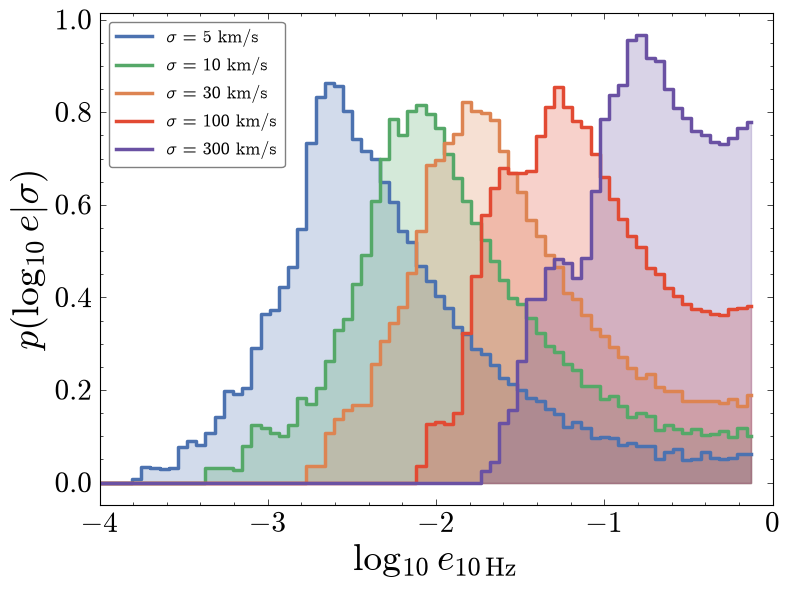


Figure saved as '../figures/ecc_distribution.pdf'


In [4]:
# ============================================================
# Compute eccentricity distributions for different sigma values
# ============================================================

# Representative sigma values (1D velocity dispersion, in km/s) spanning GC to NSC environments
sigma_values_km_s = [5, 10, 30, 100, 300]
sigma_values_cm_s = [s * 1e5 for s in sigma_values_km_s]

# Reference masses (typical for GW capture events)
M1, M2 = 30.0, 10.0  # Solar masses
Mtot = M1 + M2
mu = M1 * M2 / Mtot

# Color palette for different sigmas (using COLORS scheme)
ecc_colors = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['red'], COLORS['purple']]

print("Computing eccentricity distributions for different sigma values...")
ecc_distributions = {}
for sig_km_s, sig_cm_s in zip(sigma_values_km_s, sigma_values_cm_s):
    print(f"  sigma = {sig_km_s} km/s...")
    eccs, pdf, edges = p_e_given_sigma_Mtot_mu(sig_cm_s, Mtot, mu)
    ecc_distributions[sig_km_s] = (eccs, pdf, edges)
print("Done!")

# ============================================================
# Eccentricity distributions for different sigma
# ============================================================
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

for (sig_km_s, (eccs, pdf, edges)), color in zip(ecc_distributions.items(), ecc_colors):
    log10_eccs = np.log10(eccs)
    # Transform p(e) to p(log10(e)): p(log10(e)) = p(e) * e * ln(10)
    pdf_log10 = pdf * eccs * np.log(10)
    # Plot filled area with low opacity
    ax1.fill_between(log10_eccs, 0, pdf_log10, step='mid', color=color, alpha=0.25)
    # Plot step outline
    ax1.step(log10_eccs, pdf_log10, where='mid', color=color, lw=2.5,
             label=f'$\\sigma$ = {sig_km_s} km/s')

ax1.set_xlabel('$\\log_{{10}} e_{{10\\,\\mathrm{{Hz}}}}$', fontsize=27)
ax1.set_ylabel('$p(\\log_{{10}} e | \\sigma)$', fontsize=27)
ax1.legend(loc='upper left', fontsize=13, framealpha=1.0, edgecolor='grey', frameon=True)
ax1.set_xlim([-4.0, 0])
ax1.tick_params(axis='both', labelsize=21)

plt.tight_layout()
plt.savefig('../figures/ecc_distribution.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as '../figures/ecc_distribution.pdf'")


## Reproducing the figure from the shipped capture table

The hierarchical inference does not re-run the Monte Carlo above for every
likelihood evaluation; it reads `hierarchical_inference/capture_ecc_table.h5`,
which tabulates $p(\log_{10}e\,|\,\sigma, M_{\rm tot}, \mu)$ on a
$(\sigma, M_{\rm tot}, \mu, e)$ grid. The cell below loads that table and
reproduces the figure above by slicing to the same reference binary and
interpolating along $\log_{10}\sigma$ — a demonstration of how the table is
consumed, and a cross-check that it matches the direct Monte Carlo.

nearest table node: Mtot = 41.2 Msun, mu = 7.74 Msun


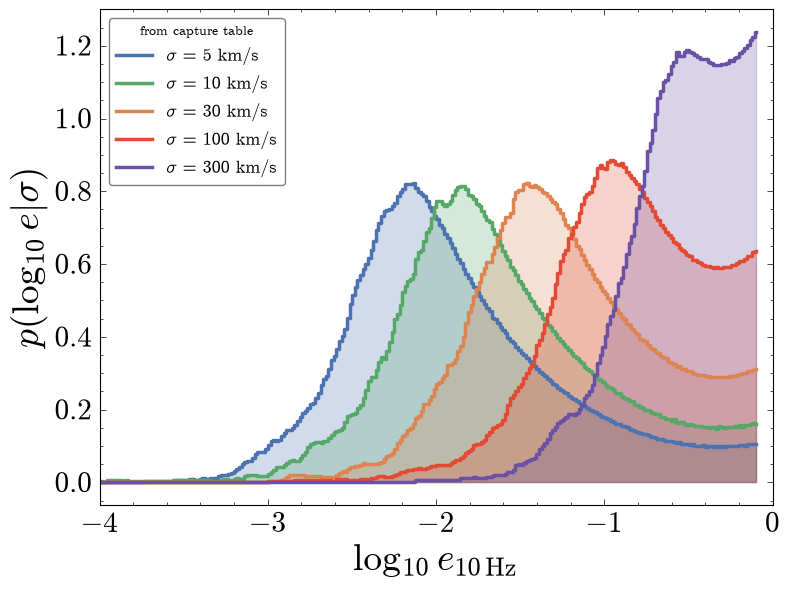

In [5]:
# ============================================================
# Same distribution, but read from the shipped capture table
# ============================================================
# `capture_ecc_table.h5` tabulates p(log10 e | sigma, Mtot, mu), precomputed from
# the Monte Carlo above on a (sigma, Mtot, mu, e) grid. Reading + interpolating
# the table is the fast path the hierarchical inference uses (instead of re-running
# the Monte Carlo per likelihood call); here we reproduce the figure above from it
# as a cross-check.
import h5py
from config import HIERARCHICAL_DIR
from download_data import download_all

TABLE = os.path.join(HIERARCHICAL_DIR, "capture_ecc_table.h5")
if not os.path.exists(TABLE):
    download_all()

with h5py.File(TABLE) as f:
    Mtot_grid = f["Mtot_grid"][:]
    mu_grid = f["mu_grid"][:]
    e_centers = f["e_centers"][:]
    sigma_grid = f["sigma_grid"][:]      # cm/s
    table = f["table"][:]                # (sigma, Mtot, mu, e) -> p(log10 e)
log10_sigma_grid = np.log10(sigma_grid)
log10_e_tab = np.log10(e_centers)

# Match the reference binary used above (Mtot = 40 Msun, mu = 7.5 Msun).
iM = int(np.argmin(np.abs(Mtot_grid - Mtot)))
iU = int(np.argmin(np.abs(mu_grid - mu)))
print(f"nearest table node: Mtot = {Mtot_grid[iM]:.1f} Msun, mu = {mu_grid[iU]:.2f} Msun")
slab = table[:, iM, iU, :]               # (sigma, e)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for sig_km_s, color in zip(sigma_values_km_s, ecc_colors):
    # Interpolate the table along log10 sigma to the requested dispersion.
    pe = np.array([np.interp(np.log10(sig_km_s * 1e5), log10_sigma_grid, slab[:, k])
                   for k in range(slab.shape[1])])
    ax.fill_between(log10_e_tab, 0, pe, step="mid", color=color, alpha=0.25)
    ax.step(log10_e_tab, pe, where="mid", color=color, lw=2.5,
            label=f"$\\sigma$ = {sig_km_s} km/s")

ax.set_xlabel("$\\log_{{10}} e_{{10\\,\\mathrm{{Hz}}}}$", fontsize=27)
ax.set_ylabel("$p(\\log_{{10}} e | \\sigma)$", fontsize=27)
ax.legend(loc="upper left", fontsize=13, framealpha=1.0, edgecolor="grey", frameon=True,
          title="from capture table")
ax.set_xlim([-4.0, 0])
ax.tick_params(axis="both", labelsize=21)
plt.tight_layout()
plt.show()